In [62]:
import cv2, numpy as np, matplotlib.pyplot as plt, glob
from tqdm import tqdm
from PIL import Image
from PIL.ExifTags import TAGS, GPSTAGS

initial_targets = sorted(glob.glob("./subset/*"))
images = sorted(glob.glob("/Volumes/SD_Card/DCIM/DJI_20260401*/*.JPG"))

target = initial_targets[-5]

# Get image coordinates and target subset
import gps
img_exif = [(im, gps.get_exif_data(im))for im in tqdm(images, "Loading EXIF Data")]
coords = np.array([gps.get_coords(i[1]) for i in tqdm(img_exif, "Extracing GPS Data")])
target_coord = gps.get_coords(target)

mask = gps.dist_from_centroid(coords, target_coord) < 2 # Use only images within 2 arcseconds of the target
np.sum(mask)

targets = np.array(images)[mask]

100%|██████████████████████████████████████████████████████████████| 1469/1469 [00:00<00:00, 269340.47it/s]


(np.float64(-0.5), np.float64(36959.5), np.float64(3955.5), np.float64(-0.5))

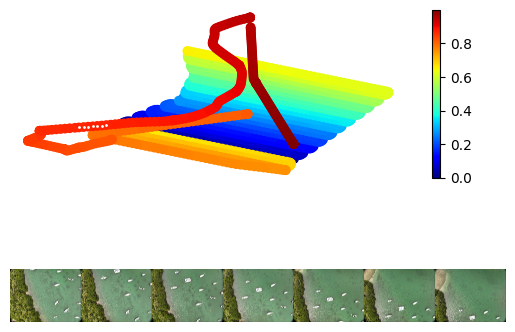

In [2]:
LATLON = gps.to_arc_seconds(coords)

fig, axs = plt.subplots(2)

c = axs[0].scatter(
    LATLON[:, 0],
    LATLON[:, 1],
    c=np.arange(LATLON.shape[0]) / LATLON.shape[0],
    # s=2
    cmap='jet'
)
fig.colorbar(c)

axs[0].scatter(
    LATLON[mask][:, 0],
    LATLON[mask][:, 1],
    s=1,
    c='white'
)

axs[0].axis('off') # The axis is sometimes anisotropically scaled, which is confusing, so I turned off labels

imgs = [
    np.asarray(Image.open(im)) for im in targets
]
axs[1].imshow(np.hstack(imgs))
axs[1].axis('off')

In [3]:
import floats

float_results = [floats.find_floats(im, logs=True) for im in tqdm(images)]
# descriptors, matches = floats.match_images(targets, res, matching_query=queries, DESC_SIZE=100)
safe_transforms = floats.get_good_transforms(targets, float_results, min_correspondances=3, desc_size=100)


# queries = []
# for i in range(len(targets) - 1):
#     queries.append((i, i + 1))


  0%|                                                                                | 0/7 [00:00<?, ?it/s]2026-04-07 13:58:11.428 | DEBUG    | floats:find_floats:110 - Finding Gray Mask
2026-04-07 13:58:12.014 | DEBUG    | floats:find_floats:113 - Finding Boat Mask
2026-04-07 13:58:12.053 | DEBUG    | floats:find_floats:116 - Finding Edge Mask
2026-04-07 13:58:12.113 | DEBUG    | floats:find_floats:122 - Finding Line Mask
2026-04-07 13:58:12.125 | DEBUG    | floats:line_mask:64 - Found 19 lines

100%|██████████████████████████████████████████████████████████████████████| 19/19 [00:10<00:00,  1.84it/s]
2026-04-07 13:58:22.583 | DEBUG    | floats:find_floats:126 - Finding Circles
 14%|██████████▎                                                             | 1/7 [00:11<01:08, 11.37s/it]2026-04-07 13:58:22.802 | DEBUG    | floats:find_floats:110 - Finding Gray Mask
2026-04-07 13:58:23.394 | DEBUG    | floats:find_floats:113 - Finding Boat Mask
2026-04-07 13:58:23.428 | DEBUG    | floats:f

In [4]:
safe_transforms = floats.get_good_transforms(targets, float_results, min_correspondances=3, desc_size=100)

Creating descriptors: 0it [00:00, ?it/s]2026-04-07 13:59:56.200 | DEBUG    | floats:create_descriptors:146 - Keeping 88.89% of descriptors
Creating descriptors: 1it [00:00,  4.92it/s]2026-04-07 13:59:56.377 | DEBUG    | floats:create_descriptors:146 - Keeping 100.00% of descriptors
Creating descriptors: 2it [00:00,  5.35it/s]2026-04-07 13:59:56.551 | DEBUG    | floats:create_descriptors:146 - Keeping 100.00% of descriptors
Creating descriptors: 3it [00:00,  5.58it/s]2026-04-07 13:59:56.726 | DEBUG    | floats:create_descriptors:146 - Keeping 92.86% of descriptors
Creating descriptors: 4it [00:00,  5.66it/s]2026-04-07 13:59:56.890 | DEBUG    | floats:create_descriptors:146 - Keeping 83.33% of descriptors
Creating descriptors: 5it [00:00,  5.84it/s]2026-04-07 13:59:57.055 | DEBUG    | floats:create_descriptors:146 - Keeping 79.10% of descriptors
Creating descriptors: 6it [00:01,  5.10it/s]2026-04-07 13:59:57.304 | DEBUG    | floats:create_descriptors:146 - Keeping 66.99% of descriptors
C

In [5]:
target_coords = np.array([gps.get_coords(str(t)) for t in tqdm(targets)])

M = floats.map_coords_to_image(targets, safe_transforms, gps.to_arc_seconds(target_coords))

100%|██████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 2029.60it/s]
2026-04-07 14:00:03.507 | DEBUG    | floats:map_coords_to_image:380 - Found transform [[  288.43763086  1297.9619273 ]
 [-1250.70914434  -725.28131388]] with error: 12.36502167851176


Failed to find M for 4, 4


100%|████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.34it/s]
2026-04-07 14:00:07.239 | DEBUG    | floats:map_coords_to_image:394 - Saved target transforms


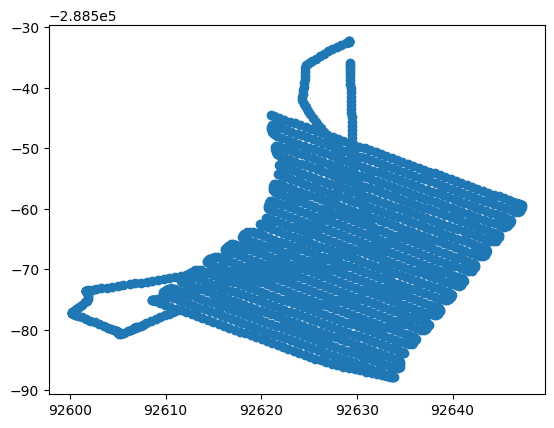

In [10]:
plt.scatter(
    LATLON[:, 0],
    LATLON[:, 1]
)

In [116]:
yaws = [gps.get_gimbal_yaw(image) for image in tqdm(targets, "Extracting Gimball Yaw")]

Extracting Gimball Yaw:   0%|                                                                                                                                                                   | 0/7 [00:00<?, ?it/s]


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [97]:
yaws_all = [gps.get_gimbal_yaw(image) for image in tqdm(images, "Extracting Gimball Yaw")]

Extracting Gimball Yaw: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1469/1469 [01:21<00:00, 18.09it/s]


In [110]:
yaws


['+12.10', -167.9, -167.9, '+12.40', '+12.40', -165.6, '+14.60']

In [100]:
def get_flight_yaw(image_path):
    cmd = [
        "exiftool",
        "-json",
        "-FlightYawDegree",
        image_path
    ]
    
    result = subprocess.run(cmd, capture_output=True, text=True)
    data = json.loads(result.stdout)[0]
    
    return data.get("FlightYawDegree")

In [74]:
np.array(pitches_all)[np.abs(np.array(pitches_all) - -90) > 0.3]

array([-45. , -45. , -44.9, -45. , -44.9, -44.9, -44.9, -44.9, -45. ,
       -44.9, -44.9, -44.9, -45. , -45. , -44.9, -44.9, -44.9, -45. ,
       -45. , -44.9, -44.9, -45. , -44.9, -44.9, -44.9, -45. , -44.9,
       -45. , -44.9, -44.9, -45. , -45. , -45. , -44.9, -45. , -45. ,
       -45. , -45. , -45. , -45. , -44.9])

In [75]:
def get_image_transform(gimball_pitch, image_shape):
    ctr = np.array(image_shape[:2][::-1]) / 2
    gimball_pitch = gimball_pitch / 180 * np.pi 
    c = np.cos(gimball_pitch)
    s = np.cos(gimball_pitch)
    rot = np.array([
        [c, -s],
        [s, c]
    ])
    return ctr, rot.T # Convert to inverse

In [95]:
import json

In [86]:
shape = np.asarray(Image.open(targets[0])).shape

In [87]:
get_image_transform(pitches[0], shape)

(array([2640., 1978.]),
 array([[ 0.00174533,  0.00174533],
        [-0.00174533,  0.00174533]]))

In [90]:

def get_gimbal_yaw(image_path):
    cmd = [
        "exiftool",
        "-json",
        "-GimbalYawDegree",
        image_path
    ]
    
    result = subprocess.run(cmd, capture_output=True, text=True)
    data = json.loads(result.stdout)[0]
    
    return data.get("GimbalYawDegree")




In [18]:
M @ images[0].shape[:2][::-1]

array([ 6657688.07531646, -9472957.15983527])

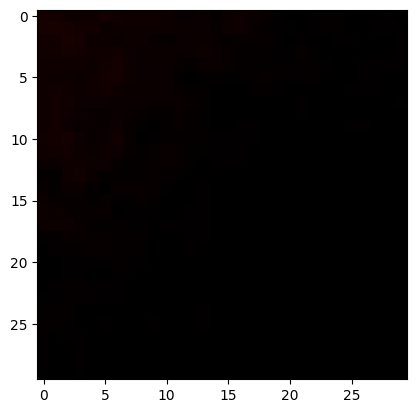

In [59]:
path = "/Users/noahpikielny/Desktop/Work/Sargassum/Registration/subset/DJI_20260401153130_0082_V.JPG"
im1 = np.mean(np.asarray(Image.open(path)), axis=-1)
T0 = (np.array(im1.shape[::-1])) @ np.linalg.inv(M)
t = T0 @ M
warped = cv2.warpAffine(im1, np.array([[1, 0, t[0]], [0, 1, t[1]]]), im1.shape[:2][::-1]).astype(np.float32)
# fig, axs = plt.subplots(1, 2)
# axs[0].imshow(np.asarray(Image.open(targets[q[0]])))
# axs[1].imshow(np.asarray(Image.open(targets[q[1]])))
# for ax in axs:
#     ax.axis('off')
plt.imshow(
    np.dstack([
        im1,
        warped,
        np.zeros_like(im1)
    ])[-30:, -30:] / 255 * 2
)
# plt.imshow(warped / 255)

In [6]:
raise Help

NameError: name 'Help' is not defined

In [ ]:

translations = np.array([t for _, t in safe_transforms])

In [ ]:
def ransac_transform(A, B):
    assert(A.shape[0] >= 2)
    def solve(v1, v2, z1, z2):
        # AM = B
        # M = A^-1 B
        
        a = np.vstack([
            v1, v2
        ])

        b = np.vstack([
            z1, z2
        ])
        a_inv = np.linalg.inv(a)
        return a_inv @ b

    best_M = None
    best_score = np.inf
    for i in range(A.shape[0]):
        for j in range(A.shape[0]):
            if i == j:
                continue
        try:
            M = solve(
                A[i],
                A[j],
                B[i],
                B[j]
            )
        except:
            print(f"Failed to find M for {i}, {j}")
        score = np.linalg.norm(A @ M - B, axis=-1)
        score = np.median(score)
        if score < best_score:
            best_M = M
            best_score = score
    return best_M,  best_score
    

In [ ]:
M, s = ransac_transform(offsets, translations)
s

In [ ]:
for idx, q in enumerate(tqdm(safe_transforms)):
    q = q[0]
    t = offsets[idx] @ M
    im1 = np.mean(np.asarray(Image.open(targets[q[0]])), axis=-1)
    warped = cv2.warpAffine(im1, np.array([[1, 0, t[0]], [0, 1, t[1]]]), im1.shape[:2][::-1])
    im2 = np.mean(np.asarray(Image.open(targets[q[1]])), axis=-1)
    # result = (
    #     (warped + im2) / 2
    # )
    result = np.dstack([
        warped,
        im2,
        np.zeros_like(im1)
    ]).astype(np.uint8)
    cv2.imwrite(f"rewarping_{idx}.jpg", result.astype(np.uint8))

In [ ]:
ID = 0
q = safe_transforms[ID][0]
t = offsets[ID] @ M
im1 = np.asarray(Image.open(targets[q[0]]))
warped = cv2.warpAffine(im1, np.array([[1, 0, t[0]], [0, 1, t[1]]]), im1.shape[:2][::-1]).astype(np.float32)
im2 = np.asarray(Image.open(targets[q[1]])).astype(np.float32)
# fig, axs = plt.subplots(1, 2)
# axs[0].imshow(np.asarray(Image.open(targets[q[0]])))
# axs[1].imshow(np.asarray(Image.open(targets[q[1]])))
# for ax in axs:
#     ax.axis('off')
plt.imshow(
    (warped + im2) / (255 * 2)
)
# plt.imshow(warped / 255)

In [ ]:
t

In [ ]:
translations

In [ ]:
# homog = np.vstack([M, [[0, 0]]]).T # Now can left multiply instead of right multiply
# homog

In [ ]:
M.shape

In [ ]:
offsets @ M - translations

In [ ]:
np.vstack([[1, 2], [3, 4]])

In [ ]:
# offsets
# translations

In [ ]:
coords1

In [ ]:
descriptors, matches = floats.match_images(targets, res, matching_query=queries, DESC_SIZE=100)

In [ ]:
pitches = [gps.get_gimbal_pitch(t) for t in targets]

In [ ]:
pitches

In [ ]:
translations = []

for Q in tqdm(range(len(queries))):
    q = queries[Q]
    P1 = targets[q[0]]
    P2 = targets[q[1]]
    M = matches[Q][0]
    mask = matches[Q][1]
    
    C1 = descriptors[q[0]][0][mask.astype(bool)]
    C2 = descriptors[q[1]][0]
    
    c = floats.draw_matches(P1, P2, M, C1, C2)
    cv2.imwrite(f"match_{Q}.jpg", c[..., ::-1])
    t, b, s, count, mask = ransac_d(C1, C2[M[:, 0].astype(int)], error=30)
    # t, b, s, count, mask = ransac_e(C1, C2[M[:, 0].astype(int)])
    np.sum(mask)
    if count > 2:
        translations.append(t)
    translations.append(t)

    c = floats.draw_matches(P1, P2, M[mask], C1[mask], C2)
    cv2.imwrite(f"ransac_match_{Q}.jpg", c[..., ::-1])

In [ ]:

def ransac_d(c1, c2, error=0.01):
    t = c2 - c1
    best = 0
    best_count = -np.inf
    best_score = np.inf
    for idx, i in enumerate(t):
        score = np.linalg.norm(t - i, axis=-1)
        # score = (t @ i) / (i @ i)
        mask = score < error
        s = np.sum(mask)
        score = np.mean(score[mask])
        print(s, score)
        if s > best_count or s == best_count and score < best_score:
            best = idx
            best_count = s
            best_score = score

    score = np.linalg.norm(t - t[best], axis=-1)
    mask = score < error
    return t[best], best, best_score, best_count, mask

In [ ]:

def ransac_e(c1, c2):
    aff, inl = cv2.estimateAffinePartial2D(c1, c2)
    # t = c2 - c1
    # best = 0
    # best_count = -np.inf
    # best_score = np.inf
    # for idx, i in enumerate(t):
    #     score = np.linalg.norm(t - i, axis=-1)
    #     # score = (t @ i) / (i @ i)
    #     mask = score < error
    #     s = np.sum(mask)
    #     score = np.mean(score[mask])
    #     print(s, score)
    #     if s > best_count or s == best_count and score < best_score:
    #         best = idx
    #         best_count = s
    #         best_score = score

    # score = np.linalg.norm(t - t[best], axis=-1)
    # mask = score < error
    # return t[best], best, best_score, best_count, mask
    return aff, 0, 0, np.sum(inl), inl[:, 0].astype(bool)

In [ ]:
Q = -1
q = queries[Q]
P1 = targets[q[0]]
P2 = targets[q[1]]
M = matches[Q][0]
mask = matches[Q][1]

C1 = descriptors[q[0]][0][mask.astype(bool)]
C2 = descriptors[q[1]][0]

c1 = floats.draw_matches(P1, P2, M, C1, C2)
# cv2.imwrite(f"match_{Q}.jpg", c[..., ::-1])
t, b, s, count, mask = ransac_e(C1, C2[M[:, 0].astype(int)])
np.sum(mask)
if count > 2:
    translations.append(t)
translations.append(t)

c2 = floats.draw_matches(P1, P2, M[mask], C1[mask], C2)
# cv2.imwrite(f"ransac_match_{Q}.jpg", c[..., ::-1])

In [ ]:
plt.imshow(c1)

In [ ]:
plt.imshow(c2)
plt.axis('off')

In [ ]:
np.linalg.norm(t, axis=-1)